In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)

PROJECT = Path('.')
DATA = PROJECT / 'data'
MODELS = DATA / 'models'
FEATURES = DATA / 'features'

print('Setup complete')

Setup complete


In [2]:
df = pd.read_parquet(FEATURES / 'feature_matrix_v2.parquet')
print(f'Feature matrix: {df.shape}')
print(f'Labels: {df["label"].value_counts().to_dict()}')
print(f'Date range: {df["t0"].min()} -> {df["t0"].max()}')

with open(MODELS / 'model_meta_v2.json') as f:
    meta = json.load(f)

FEATURES_LIST = meta['features']
print(f'Features: {len(FEATURES_LIST)}')

lgb_model = joblib.load(MODELS / 'lgb_model_v2.joblib')
xgb_model = joblib.load(MODELS / 'xgb_model_v2.joblib')
calibrators = joblib.load(MODELS / 'calibrators_v2.joblib')

with open(MODELS / 'model_meta_v1.json') as f:
    meta_v1 = json.load(f)
train_medians = np.array(meta_v1['train_medians'])

print(f'Models loaded: LGB, XGB, calibrators')

Feature matrix: (43461, 94)
Labels: {-1: 17546, 1: 17537, 0: 8378}
Date range: 2025-12-05 20:00:00+00:00 -> 2026-03-05 23:00:00+00:00
Features: 63
Models loaded: LGB, XGB, calibrators


In [3]:
df_bin = df[df['label'] != 0].copy()
df_bin['y'] = (df_bin['label'] == 1).astype(int)
print(f'Binary samples: {len(df_bin)} (TP={df_bin["y"].sum()}, SL={(df_bin["y"]==0).sum()})')

df_bin = df_bin.sort_values('t0').reset_index(drop=True)
n = len(df_bin)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train = df_bin.iloc[:n_train]
val = df_bin.iloc[n_train:n_train+n_val]
test = df_bin.iloc[n_train+n_val:]

print(f'Train: {len(train)} ({train["t0"].min().date()} -> {train["t0"].max().date()})')
print(f'Val:   {len(val)} ({val["t0"].min().date()} -> {val["t0"].max().date()})')
print(f'Test:  {len(test)} ({test["t0"].min().date()} -> {test["t0"].max().date()})')

def prepare_X(data):
    X = data[FEATURES_LIST].values.copy()
    for j in range(X.shape[1]):
        mask = np.isnan(X[:, j])
        if mask.any():
            X[mask, j] = train_medians[j]
    return X

X_train, y_train = prepare_X(train), train['y'].values
X_val, y_val = prepare_X(val), val['y'].values
X_test, y_test = prepare_X(test), test['y'].values

print(f'\nFeature shapes: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}')

Binary samples: 35083 (TP=17537, SL=17546)
Train: 24558 (2025-12-05 -> 2026-02-06)
Val:   5262 (2026-02-06 -> 2026-02-22)
Test:  5263 (2026-02-22 -> 2026-03-05)

Feature shapes: train=(24558, 63), val=(5262, 63), test=(5263, 63)


In [4]:
lgb_raw_val = lgb_model.predict_proba(X_val)[:, 1]
lgb_raw_test = lgb_model.predict_proba(X_test)[:, 1]

platt_lr = calibrators['platt_lgb']

prob_val = platt_lr.predict_proba(lgb_raw_val.reshape(-1, 1))[:, 1]
prob_test = platt_lr.predict_proba(lgb_raw_test.reshape(-1, 1))[:, 1]

print(f'Calibrated probabilities:')
print(f'  Val:  mean={prob_val.mean():.4f}, std={prob_val.std():.4f}, range=[{prob_val.min():.4f}, {prob_val.max():.4f}]')
print(f'  Test: mean={prob_test.mean():.4f}, std={prob_test.std():.4f}, range=[{prob_test.min():.4f}, {prob_test.max():.4f}]')

Calibrated probabilities:
  Val:  mean=0.5005, std=0.1627, range=[0.1424, 0.8546]
  Test: mean=0.5027, std=0.1736, range=[0.1406, 0.8622]


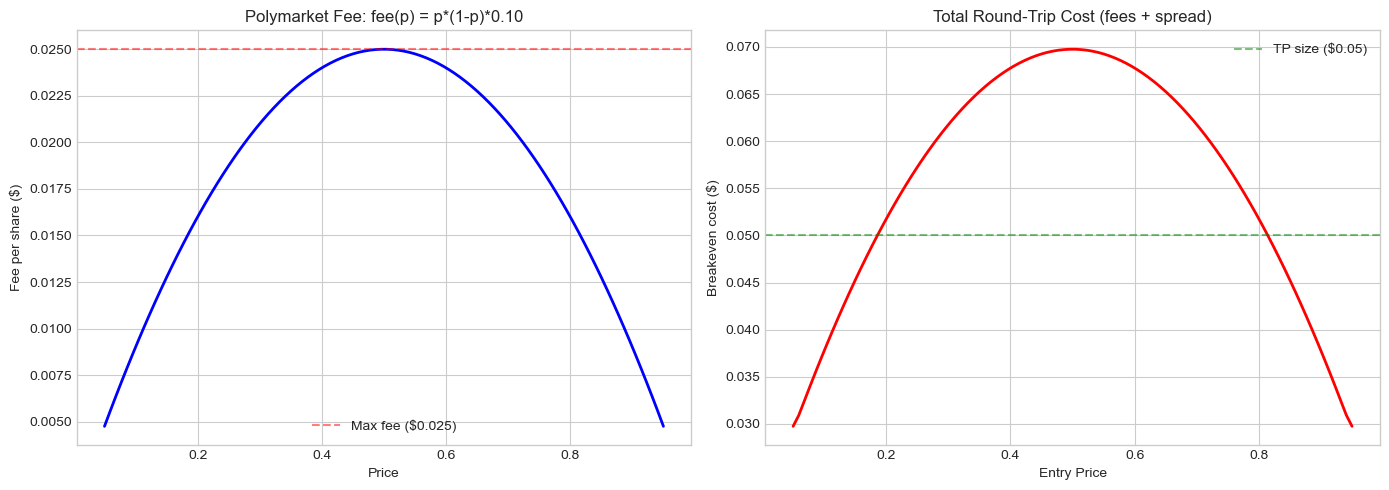


 Price |      Fee |  RT Cost | Cost/TP%
----------------------------------------
  0.10 | $ 0.0090 | $ 0.0378 |    75.5%
  0.20 | $ 0.0160 | $ 0.0518 |   103.5%
  0.30 | $ 0.0210 | $ 0.0618 |   123.5%
  0.40 | $ 0.0240 | $ 0.0678 |   135.5%
  0.50 | $ 0.0250 | $ 0.0698 |   139.5%
  0.60 | $ 0.0240 | $ 0.0678 |   135.5%
  0.70 | $ 0.0210 | $ 0.0618 |   123.5%
  0.80 | $ 0.0160 | $ 0.0517 |   103.5%
  0.90 | $ 0.0090 | $ 0.0377 |    75.5%


In [5]:
FEE_RATE = 0.10
SPREAD = 0.02
TP_SIZE = 0.05
SL_SIZE = 0.05

def poly_fee(price):
    """Polymarket fee per share at given price."""
    p = np.clip(price, 0.01, 0.99)
    return p * (1 - p) * FEE_RATE

def total_cost(p_entry, p_exit, spread=SPREAD):
    """Total round-trip cost per share."""
    return poly_fee(p_entry) + poly_fee(p_exit) + spread

def breakeven_edge(p_entry, spread=SPREAD):
    """Minimum edge needed to break even at this price level."""

    cost_tp = total_cost(p_entry, p_entry + TP_SIZE, spread)
    cost_sl = total_cost(p_entry, p_entry - SL_SIZE, spread)
    avg_cost = (cost_tp + cost_sl) / 2
    return avg_cost

prices = np.linspace(0.05, 0.95, 100)
fees = [poly_fee(p) for p in prices]
be_edges = [breakeven_edge(p) for p in prices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prices, fees, 'b-', linewidth=2)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Fee per share ($)')
axes[0].set_title('Polymarket Fee: fee(p) = p*(1-p)*0.10')
axes[0].axhline(y=0.025, color='r', linestyle='--', alpha=0.5, label='Max fee ($0.025)')
axes[0].legend()

axes[1].plot(prices, be_edges, 'r-', linewidth=2)
axes[1].set_xlabel('Entry Price')
axes[1].set_ylabel('Breakeven cost ($)')
axes[1].set_title('Total Round-Trip Cost (fees + spread)')
axes[1].axhline(y=TP_SIZE, color='g', linestyle='--', alpha=0.5, label=f'TP size (${TP_SIZE})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n{"Price":>6} | {"Fee":>8} | {"RT Cost":>8} | {"Cost/TP%":>8}')
print('-' * 40)
for p in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    f = poly_fee(p)
    c = breakeven_edge(p)
    print(f'{p:6.2f} | ${f:7.4f} | ${c:7.4f} | {c/TP_SIZE*100:7.1f}%')

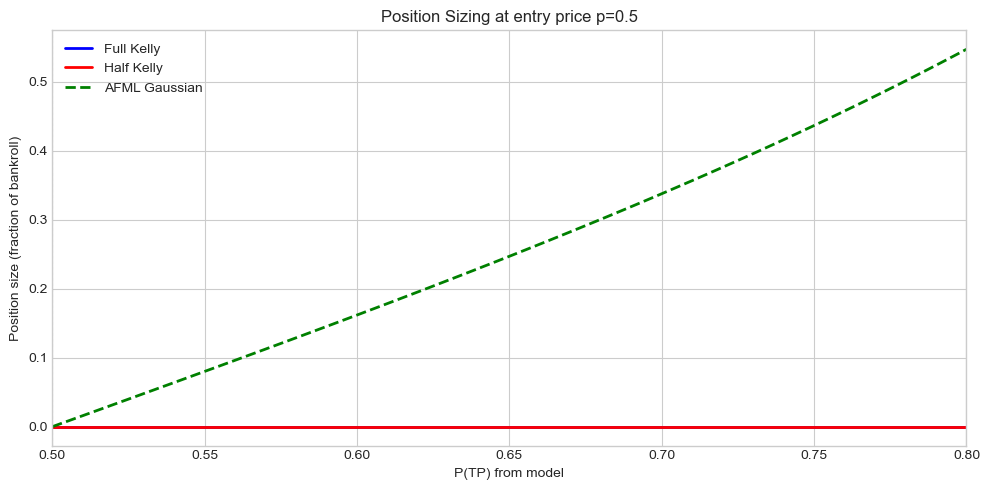

In [6]:
def kelly_fraction(p_win, win_amount, loss_amount, fraction=0.5):
    """Kelly criterion for binary outcomes.

    Args:
        p_win: probability of winning
        win_amount: net profit if win (after fees)
        loss_amount: net loss if lose (after fees, positive number)
        fraction: Kelly fraction (0.5 = half-Kelly)
    Returns:
        f: fraction of bankroll to bet
    """
    if win_amount <= 0 or loss_amount <= 0:
        return 0.0
    b = win_amount / loss_amount
    q = 1 - p_win
    f = (p_win * b - q) / b
    f = max(0, f) * fraction
    return f

def gaussian_betsize(prob, num_classes=2):
    """AFML ch.10: probability -> bet size via Gaussian transform.
    Maps [0,1] probability to [0,1] position size (unsigned).
    """
    p = np.clip(prob, 1e-4, 1 - 1e-4)
    signal = (p - 1.0 / num_classes) / np.sqrt(p * (1 - p))
    size = 2 * norm.cdf(signal) - 1
    return np.clip(size, 0, 1)

def compute_position_size(p_model, p_market, kelly_frac=0.5, max_position=0.10):
    """Compute position size for a single trade.

    Args:
        p_model: model's predicted P(TP)
        p_market: market price (entry price)
        kelly_frac: Kelly fraction (default 0.5 = half-Kelly)
        max_position: max fraction of bankroll per trade
    Returns:
        position_frac: fraction of bankroll to allocate
    """

    cost_tp = total_cost(p_market, p_market + TP_SIZE)
    cost_sl = total_cost(p_market, max(0.01, p_market - SL_SIZE))

    win_net = TP_SIZE - cost_tp
    loss_net = SL_SIZE + cost_sl

    if win_net <= 0:
        return 0.0

    f = kelly_fraction(p_model, win_net, loss_net, fraction=kelly_frac)
    return min(f, max_position)

p_models = np.linspace(0.50, 0.80, 100)
p_market = 0.50

kelly_full = [compute_position_size(pm, p_market, kelly_frac=1.0, max_position=1.0) for pm in p_models]
kelly_half = [compute_position_size(pm, p_market, kelly_frac=0.5, max_position=1.0) for pm in p_models]
gauss_size = [gaussian_betsize(pm) for pm in p_models]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_models, kelly_full, 'b-', label='Full Kelly', linewidth=2)
ax.plot(p_models, kelly_half, 'r-', label='Half Kelly', linewidth=2)
ax.plot(p_models, gauss_size, 'g--', label='AFML Gaussian', linewidth=2)
ax.axvline(x=0.50, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('P(TP) from model')
ax.set_ylabel('Position size (fraction of bankroll)')
ax.set_title(f'Position Sizing at entry price p={p_market}')
ax.legend()
ax.set_xlim(0.50, 0.80)
plt.tight_layout()
plt.show()

In [7]:
def compute_trade_ev(p_model, p_market):
    """Expected value per $1 risked for a single trade."""
    cost_tp = total_cost(p_market, min(0.99, p_market + TP_SIZE))
    cost_sl = total_cost(p_market, max(0.01, p_market - SL_SIZE))

    win_net = TP_SIZE - cost_tp
    loss_net = SL_SIZE + cost_sl

    ev = p_model * win_net - (1 - p_model) * loss_net
    return ev

val_prices = val['p_price'].values
val_ev = np.array([compute_trade_ev(p, m) for p, m in zip(prob_val, val_prices)])

print(f'Validation EV stats:')
print(f'  Mean: {val_ev.mean():.6f}')
print(f'  Std:  {val_ev.std():.6f}')
print(f'  Min:  {val_ev.min():.6f}')
print(f'  Max:  {val_ev.max():.6f}')
print(f'  % positive: {(val_ev > 0).mean()*100:.1f}%')

Validation EV stats:
  Mean: -0.060120
  Std:  0.019061
  Min:  -0.103708
  Max:  -0.001112
  % positive: 0.0%


In [8]:
def simulate_trades(probs, prices, labels, edge_threshold,
                    kelly_frac=0.5, max_pos=0.10, initial_bankroll=1000.0):
    """Simulate trades and return metrics."""
    bankroll = initial_bankroll
    equity_curve = [bankroll]
    trades = []

    for i in range(len(probs)):
        p_model = probs[i]
        p_market = prices[i]
        label = labels[i]

        ev = compute_trade_ev(p_model, p_market)
        if ev <= edge_threshold:
            equity_curve.append(bankroll)
            continue

        pos_frac = compute_position_size(p_model, p_market, kelly_frac, max_pos)
        if pos_frac <= 0:
            equity_curve.append(bankroll)
            continue

        bet_size = bankroll * pos_frac
        n_shares = bet_size / p_market

        cost_entry = poly_fee(p_market) * n_shares
        if label == 1:
            p_exit = min(0.99, p_market + TP_SIZE)
            pnl = TP_SIZE * n_shares
        else:
            p_exit = max(0.01, p_market - SL_SIZE)
            pnl = -SL_SIZE * n_shares

        cost_exit = poly_fee(p_exit) * n_shares
        spread_cost = SPREAD * n_shares

        net_pnl = pnl - cost_entry - cost_exit - spread_cost
        bankroll += net_pnl

        trades.append({
            'p_model': p_model,
            'p_market': p_market,
            'ev': ev,
            'pos_frac': pos_frac,
            'bet_size': bet_size,
            'n_shares': n_shares,
            'label': label,
            'gross_pnl': pnl,
            'fees': cost_entry + cost_exit,
            'spread': spread_cost,
            'net_pnl': net_pnl,
            'bankroll': bankroll,
        })
        equity_curve.append(bankroll)

    return trades, equity_curve

def compute_metrics(trades, equity_curve, initial_bankroll=1000.0):
    """Compute strategy metrics. Always returns same keys."""
    empty = {
        'n_trades': 0, 'total_pnl': 0.0, 'total_pnl_pct': 0.0,
        'win_rate': 0.0, 'sharpe': 0.0, 'max_dd': 0.0,
        'avg_pnl': 0.0, 'avg_pos_frac': 0.0, 'total_fees': 0.0,
        'fee_pct_of_gross': 0.0,
    }
    if len(trades) == 0:
        return empty

    df_t = pd.DataFrame(trades)

    total_pnl = df_t['net_pnl'].sum()
    total_pnl_pct = total_pnl / initial_bankroll * 100
    win_rate = (df_t['net_pnl'] > 0).mean()

    returns = df_t['net_pnl'] / df_t['bet_size']
    sharpe = returns.mean() / returns.std() if returns.std() > 0 else 0

    eq = np.array(equity_curve)
    peak = np.maximum.accumulate(eq)
    dd = (peak - eq) / peak
    max_dd = dd.max()

    total_fees = df_t['fees'].sum() + df_t['spread'].sum()
    gross_abs = abs(df_t['gross_pnl'].sum())

    return {
        'n_trades': len(trades),
        'total_pnl': total_pnl,
        'total_pnl_pct': total_pnl_pct,
        'win_rate': win_rate,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'avg_pnl': df_t['net_pnl'].mean(),
        'avg_pos_frac': df_t['pos_frac'].mean(),
        'total_fees': total_fees,
        'fee_pct_of_gross': total_fees / gross_abs if gross_abs > 0 else 0,
    }

thresholds = np.arange(0.000, 0.015, 0.001)
val_results = []

for th in thresholds:
    trades, eq = simulate_trades(prob_val, val_prices, y_val,
                                 edge_threshold=th, kelly_frac=0.5, max_pos=0.10)
    m = compute_metrics(trades, eq)
    m['threshold'] = th
    val_results.append(m)

df_val_results = pd.DataFrame(val_results)
print(df_val_results[['threshold', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']].to_string(index=False))

 threshold  n_trades  total_pnl_pct  win_rate  sharpe  max_dd
     0.000         0            0.0       0.0     0.0     0.0
     0.001         0            0.0       0.0     0.0     0.0
     0.002         0            0.0       0.0     0.0     0.0
     0.003         0            0.0       0.0     0.0     0.0
     0.004         0            0.0       0.0     0.0     0.0
     0.005         0            0.0       0.0     0.0     0.0
     0.006         0            0.0       0.0     0.0     0.0
     0.007         0            0.0       0.0     0.0     0.0
     0.008         0            0.0       0.0     0.0     0.0
     0.009         0            0.0       0.0     0.0     0.0
     0.010         0            0.0       0.0     0.0     0.0
     0.011         0            0.0       0.0     0.0     0.0
     0.012         0            0.0       0.0     0.0     0.0
     0.013         0            0.0       0.0     0.0     0.0
     0.014         0            0.0       0.0     0.0     0.0


No viable thresholds with >=20 trades, using default: 0.001


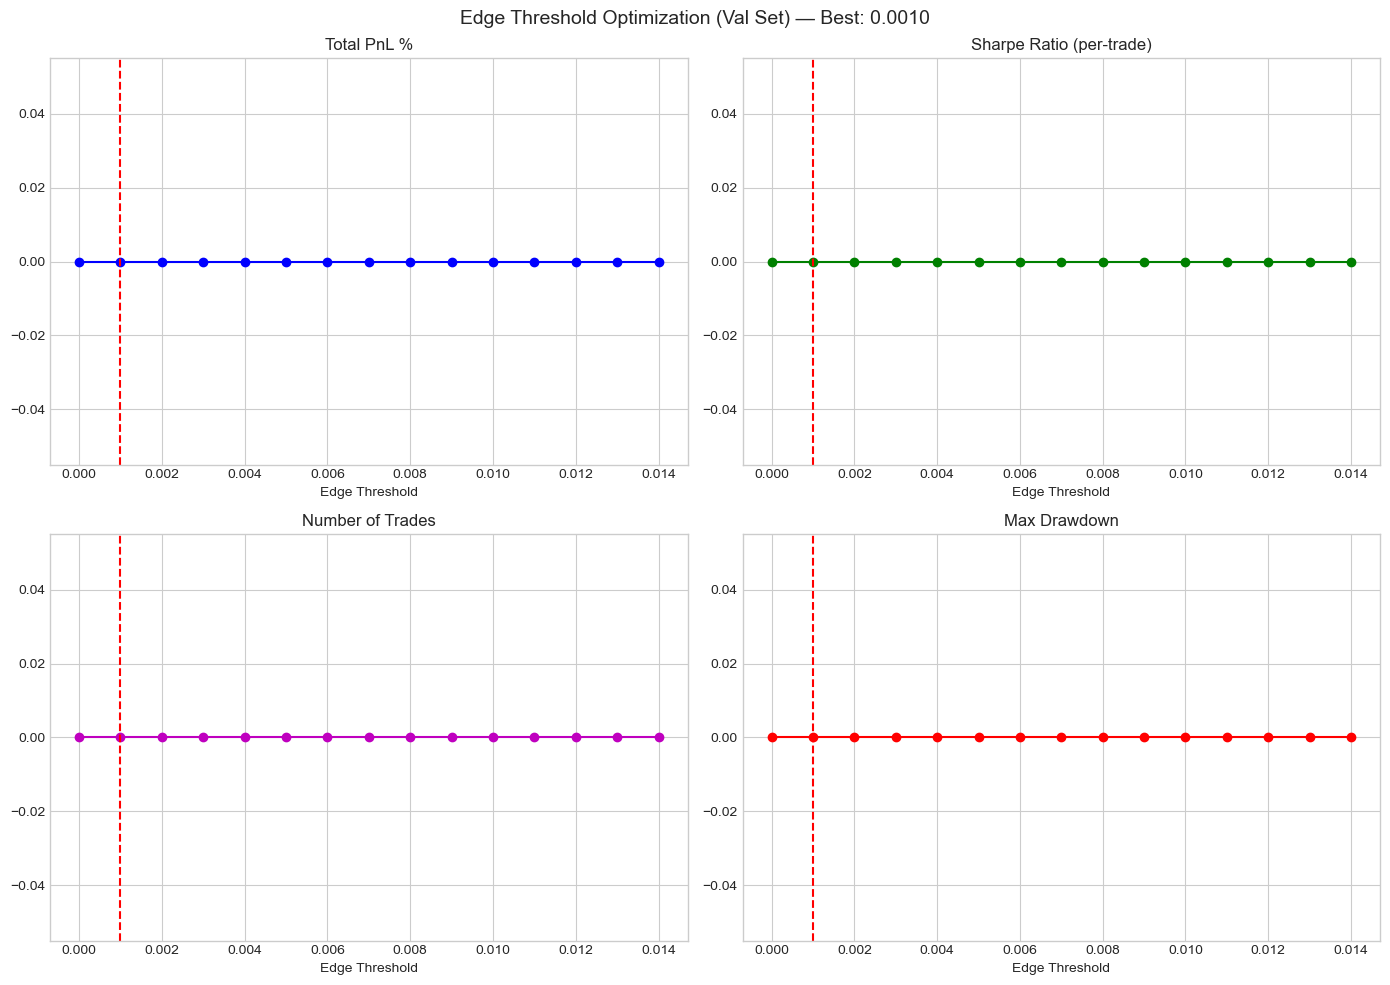

In [9]:
viable = df_val_results[df_val_results['n_trades'] >= 20].copy()
if len(viable) > 0:
    best_idx = viable['sharpe'].idxmax()
    best_threshold = viable.loc[best_idx, 'threshold']
    print(f'Best edge threshold: {best_threshold:.4f}')
    print(f'Val metrics at best threshold:')
    print(viable.loc[best_idx].to_string())
else:
    best_threshold = 0.001
    print(f'No viable thresholds with >=20 trades, using default: {best_threshold}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(df_val_results['threshold'], df_val_results['total_pnl_pct'], 'b-o')
axes[0,0].axvline(x=best_threshold, color='r', linestyle='--')
axes[0,0].set_title('Total PnL %')
axes[0,0].set_xlabel('Edge Threshold')

axes[0,1].plot(df_val_results['threshold'], df_val_results['sharpe'], 'g-o')
axes[0,1].axvline(x=best_threshold, color='r', linestyle='--')
axes[0,1].set_title('Sharpe Ratio (per-trade)')
axes[0,1].set_xlabel('Edge Threshold')

axes[1,0].plot(df_val_results['threshold'], df_val_results['n_trades'], 'm-o')
axes[1,0].axvline(x=best_threshold, color='r', linestyle='--')
axes[1,0].set_title('Number of Trades')
axes[1,0].set_xlabel('Edge Threshold')

axes[1,1].plot(df_val_results['threshold'], df_val_results['max_dd'], 'r-o')
axes[1,1].axvline(x=best_threshold, color='r', linestyle='--')
axes[1,1].set_title('Max Drawdown')
axes[1,1].set_xlabel('Edge Threshold')

plt.suptitle(f'Edge Threshold Optimization (Val Set) — Best: {best_threshold:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
test_prices = test['p_price'].values
INITIAL_BANKROLL = 1000.0

test_trades, test_equity = simulate_trades(
    prob_test, test_prices, y_test,
    edge_threshold=best_threshold,
    kelly_frac=0.5,
    max_pos=0.10,
    initial_bankroll=INITIAL_BANKROLL
)

test_metrics = compute_metrics(test_trades, test_equity, INITIAL_BANKROLL)

print('='*50)
print('TEST SET BACKTEST RESULTS')
print('='*50)
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f'  {k:>20}: {v:.4f}')
    else:
        print(f'  {k:>20}: {v}')
print(f'\nFinal bankroll: ${test_equity[-1]:.2f} (started ${INITIAL_BANKROLL:.2f})')

TEST SET BACKTEST RESULTS
              n_trades: 0
             total_pnl: 0.0000
         total_pnl_pct: 0.0000
              win_rate: 0.0000
                sharpe: 0.0000
                max_dd: 0.0000
               avg_pnl: 0.0000
          avg_pos_frac: 0.0000
            total_fees: 0.0000
      fee_pct_of_gross: 0.0000

Final bankroll: $1000.00 (started $1000.00)


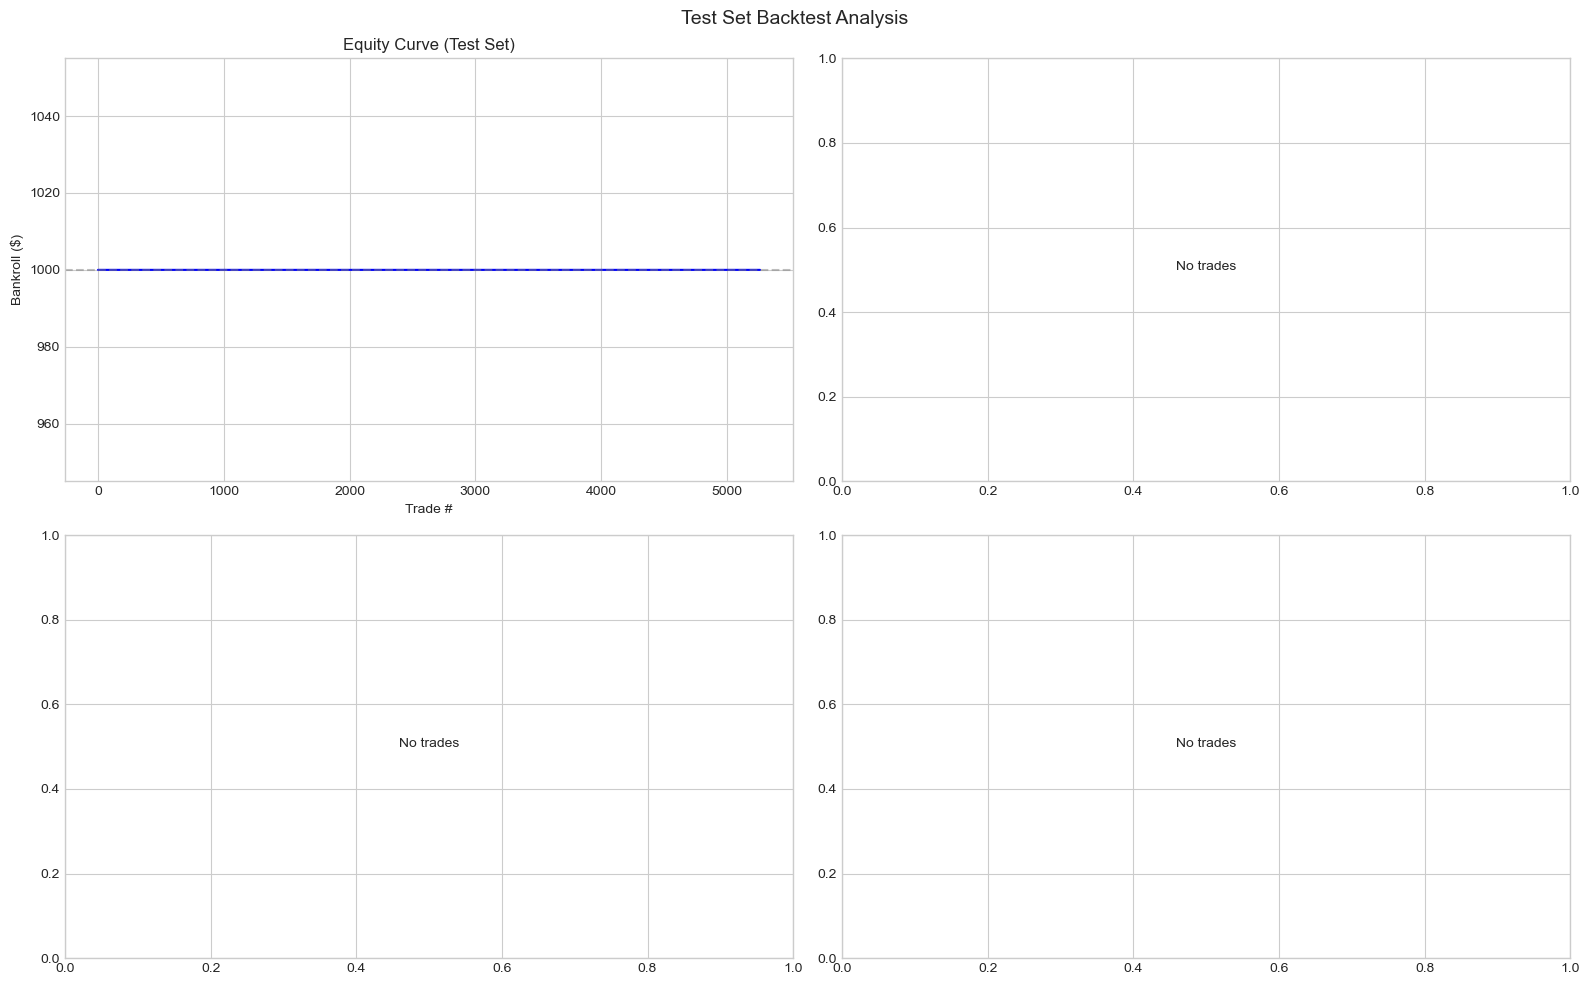

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(test_equity, 'b-', linewidth=1.5)
axes[0,0].axhline(y=INITIAL_BANKROLL, color='gray', linestyle='--', alpha=0.5)
axes[0,0].set_title('Equity Curve (Test Set)')
axes[0,0].set_xlabel('Trade #')
axes[0,0].set_ylabel('Bankroll ($)')

if len(test_trades) > 0:
    df_trades = pd.DataFrame(test_trades)

    axes[0,1].hist(df_trades['net_pnl'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,1].axvline(x=0, color='r', linestyle='--')
    axes[0,1].set_title('Per-Trade Net PnL Distribution')
    axes[0,1].set_xlabel('Net PnL ($)')

    axes[1,0].plot(df_trades['net_pnl'].cumsum(), 'g-', linewidth=1.5)
    axes[1,0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1,0].set_title('Cumulative Net PnL')
    axes[1,0].set_xlabel('Trade #')
    axes[1,0].set_ylabel('Cumulative PnL ($)')

    total_gross = df_trades['gross_pnl'].sum()
    total_fees = df_trades['fees'].sum()
    total_spread = df_trades['spread'].sum()
    total_net = df_trades['net_pnl'].sum()

    labels = ['Gross PnL', 'Fees', 'Spread', 'Net PnL']
    values = [total_gross, -total_fees, -total_spread, total_net]
    colors = ['green' if v >= 0 else 'red' for v in values]
    axes[1,1].bar(labels, values, color=colors, alpha=0.7, edgecolor='black')
    axes[1,1].set_title('PnL Decomposition')
    axes[1,1].set_ylabel('$')
    for j, v in enumerate(values):
        axes[1,1].text(j, v + 0.5, f'${v:.2f}', ha='center', fontsize=10)
else:
    for ax in [axes[0,1], axes[1,0], axes[1,1]]:
        ax.text(0.5, 0.5, 'No trades', transform=ax.transAxes, ha='center')

plt.suptitle('Test Set Backtest Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
import lightgbm as lgb

with open(MODELS / 'lgb_best_params.json') as f:
    lgb_params = json.load(f)

def walk_forward_backtest(df_data, features, min_train_days=60, test_step_days=7,
                          edge_threshold=0.001, kelly_frac=0.5, max_pos=0.10,
                          initial_bankroll=1000.0):
    """Walk-forward backtest with expanding window."""
    df_data = df_data.sort_values('t0').reset_index(drop=True)
    timestamps = df_data['t0']

    t_min = timestamps.min()
    t_max = timestamps.max()
    train_end = t_min + pd.Timedelta(days=min_train_days)

    all_trades = []
    bankroll = initial_bankroll
    equity_curve = [bankroll]
    window_metrics = []

    window_num = 0
    while train_end < t_max:
        test_end = train_end + pd.Timedelta(days=test_step_days)

        train_mask = timestamps <= train_end
        test_mask = (timestamps > train_end) & (timestamps <= test_end)

        if test_mask.sum() < 5:
            train_end = test_end
            continue

        df_tr = df_data[train_mask]
        df_te = df_data[test_mask]

        X_tr = prepare_X(df_tr)
        y_tr = df_tr['y'].values
        X_te = prepare_X(df_te)
        y_te = df_te['y'].values

        model = lgb.LGBMClassifier(**lgb_params, random_state=SEED, verbose=-1)
        model.fit(X_tr, y_tr)

        n_cal = max(50, int(len(X_tr) * 0.2))
        X_cal = X_tr[-n_cal:]
        y_cal = y_tr[-n_cal:]
        raw_cal = model.predict_proba(X_cal)[:, 1]

        cal_lr = LogisticRegression()
        cal_lr.fit(raw_cal.reshape(-1, 1), y_cal)

        raw_te = model.predict_proba(X_te)[:, 1]
        prob_te = cal_lr.predict_proba(raw_te.reshape(-1, 1))[:, 1]

        prices_te = df_te['p_price'].values
        trades_w, eq_w = simulate_trades(
            prob_te, prices_te, y_te,
            edge_threshold=edge_threshold,
            kelly_frac=kelly_frac,
            max_pos=max_pos,
            initial_bankroll=bankroll
        )

        if len(trades_w) > 0:
            bankroll = eq_w[-1]
            all_trades.extend(trades_w)
            equity_curve.extend(eq_w[1:])

        w_metrics = compute_metrics(trades_w, eq_w, eq_w[0] if len(eq_w) > 0 else bankroll)
        w_metrics['window'] = window_num
        w_metrics['train_end'] = train_end
        w_metrics['test_end'] = test_end
        w_metrics['train_size'] = train_mask.sum()
        w_metrics['test_size'] = test_mask.sum()
        window_metrics.append(w_metrics)

        window_num += 1
        train_end = test_end

    return all_trades, equity_curve, window_metrics

print('Walk-forward function defined')

Walk-forward function defined


In [13]:
print('Running walk-forward backtest...')
print(f'  Edge threshold: {best_threshold:.4f}')
print(f'  Kelly fraction: 0.5 (half-Kelly)')
print(f'  Max position: 10%')
print(f'  Initial bankroll: $1000')
print()

wf_trades, wf_equity, wf_windows = walk_forward_backtest(
    df_bin, FEATURES_LIST,
    min_train_days=60,
    test_step_days=7,
    edge_threshold=best_threshold,
    kelly_frac=0.5,
    max_pos=0.10,
    initial_bankroll=1000.0
)

wf_overall = compute_metrics(wf_trades, wf_equity, 1000.0)

print(f'\nWalk-Forward Results ({len(wf_windows)} windows):')
print(f'  Total trades: {wf_overall["n_trades"]}')
print(f'  Total PnL: ${wf_overall["total_pnl"]:.2f} ({wf_overall["total_pnl_pct"]:.1f}%)')
print(f'  Win rate: {wf_overall["win_rate"]:.1%}')
print(f'  Sharpe: {wf_overall["sharpe"]:.4f}')
print(f'  Max DD: {wf_overall["max_dd"]:.1%}')
print(f'  Final bankroll: ${wf_equity[-1]:.2f}')

Running walk-forward backtest...
  Edge threshold: 0.0010
  Kelly fraction: 0.5 (half-Kelly)
  Max position: 10%
  Initial bankroll: $1000




Walk-Forward Results (5 windows):
  Total trades: 90
  Total PnL: $1414.87 (141.5%)
  Win rate: 83.3%
  Sharpe: 0.2452
  Max DD: 31.7%
  Final bankroll: $2414.87



Per-window results:
 window  train_size  test_size  n_trades  total_pnl_pct  win_rate    sharpe   max_dd
      0       22955       3280        17      34.996651  0.764706  0.350281 0.162202
      1       26235       2056        22      61.416115  0.909091  1.016315 0.007365
      2       28291       2529        15      12.404953  0.800000  0.210655 0.080788
      3       30820       3463        33       7.819315  0.848485  0.075775 0.316857
      4       34283        800         3      -8.558970  0.666667 -0.400255 0.108239


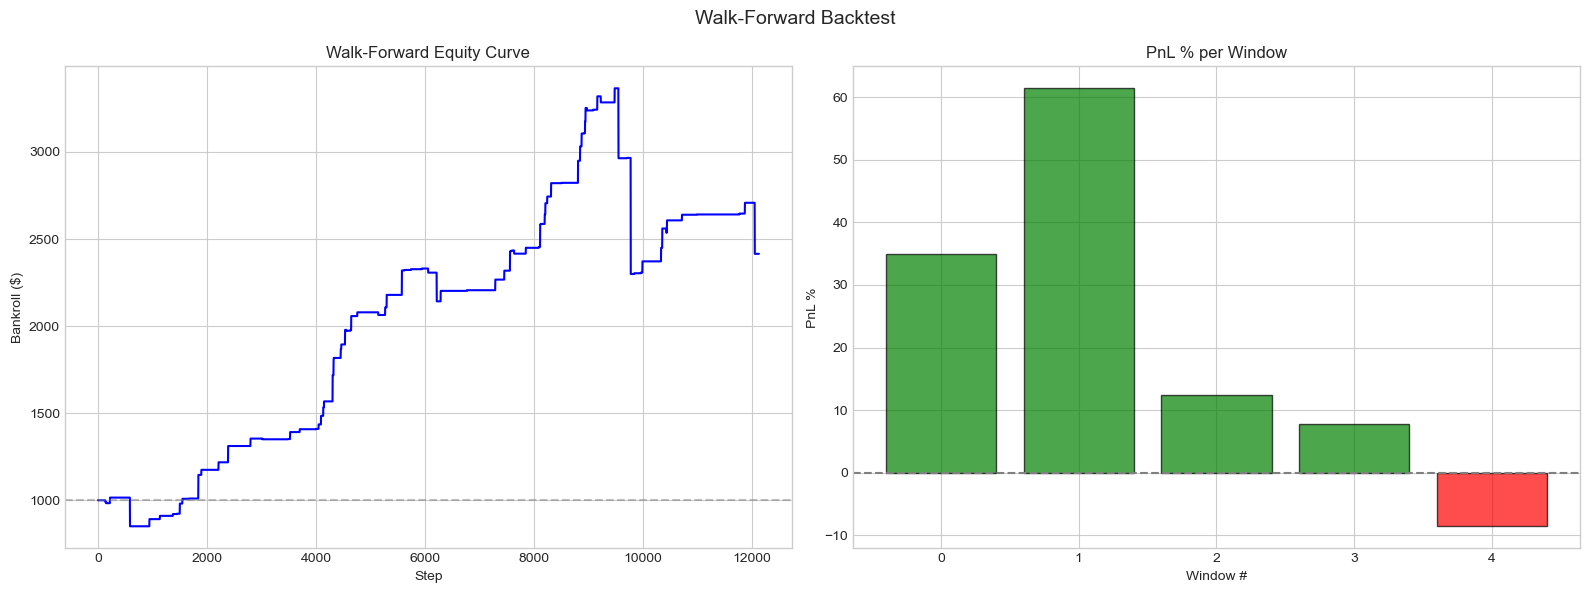

In [14]:
df_wf = pd.DataFrame(wf_windows)
print('\nPer-window results:')
cols = ['window', 'train_size', 'test_size', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']
available_cols = [c for c in cols if c in df_wf.columns]
print(df_wf[available_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(wf_equity, 'b-', linewidth=1.5)
axes[0].axhline(y=1000, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Walk-Forward Equity Curve')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Bankroll ($)')

if len(df_wf) > 0 and 'total_pnl_pct' in df_wf.columns:
    colors = ['green' if x >= 0 else 'red' for x in df_wf['total_pnl_pct']]
    axes[1].bar(range(len(df_wf)), df_wf['total_pnl_pct'], color=colors, alpha=0.7, edgecolor='black')
    axes[1].axhline(y=0, color='gray', linestyle='--')
    axes[1].set_title('PnL % per Window')
    axes[1].set_xlabel('Window #')
    axes[1].set_ylabel('PnL %')

plt.suptitle('Walk-Forward Backtest', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
if len(wf_trades) > 0:
    df_all_trades = pd.DataFrame(wf_trades)

    print('=== Risk Analysis ===')

    eq = np.array(wf_equity)
    peak = np.maximum.accumulate(eq)
    dd = (peak - eq) / peak

    print(f'\nDrawdown:')
    print(f'  Max drawdown: {dd.max():.1%}')
    print(f'  Avg drawdown: {dd[dd > 0].mean():.1%}' if (dd > 0).any() else '  Avg drawdown: 0%')

    losses = (df_all_trades['net_pnl'] < 0).astype(int)
    max_consec_loss = 0
    current = 0
    for l in losses:
        if l == 1:
            current += 1
            max_consec_loss = max(max_consec_loss, current)
        else:
            current = 0
    print(f'  Max consecutive losses: {max_consec_loss}')

    print(f'\nPosition sizing:')
    print(f'  Mean: {df_all_trades["pos_frac"].mean():.3f}')
    print(f'  Median: {df_all_trades["pos_frac"].median():.3f}')
    print(f'  Max: {df_all_trades["pos_frac"].max():.3f}')
    print(f'  Min: {df_all_trades["pos_frac"].min():.3f}')

    print(f'\nWorst 5 trades:')
    worst = df_all_trades.nsmallest(5, 'net_pnl')[['p_model', 'p_market', 'pos_frac', 'bet_size', 'net_pnl']]
    print(worst.to_string(index=False))

    print(f'\nBest 5 trades:')
    best = df_all_trades.nlargest(5, 'net_pnl')[['p_model', 'p_market', 'pos_frac', 'bet_size', 'net_pnl']]
    print(best.to_string(index=False))

    total_gross = df_all_trades['gross_pnl'].sum()
    total_fees = df_all_trades['fees'].sum()
    total_spread = df_all_trades['spread'].sum()
    total_costs = total_fees + total_spread

    print(f'\nFee Impact:')
    print(f'  Gross PnL:   ${total_gross:.2f}')
    print(f'  Total fees:  ${total_fees:.2f}')
    print(f'  Total spread: ${total_spread:.2f}')
    print(f'  Net PnL:     ${total_gross - total_costs:.2f}')
    print(f'  Costs as % of gross: {total_costs/abs(total_gross)*100:.1f}%' if total_gross != 0 else '')

    win_rate = (df_all_trades['net_pnl'] > 0).mean()
    avg_win = df_all_trades.loc[df_all_trades['net_pnl'] > 0, 'net_pnl'].mean() if win_rate > 0 else 0
    avg_loss = abs(df_all_trades.loc[df_all_trades['net_pnl'] <= 0, 'net_pnl'].mean()) if win_rate < 1 else 0

    print(f'\nTrade Statistics:')
    print(f'  Win rate: {win_rate:.1%}')
    print(f'  Avg win:  ${avg_win:.2f}')
    print(f'  Avg loss: ${avg_loss:.2f}')
    if avg_loss > 0:
        print(f'  Win/Loss ratio: {avg_win/avg_loss:.2f}')
        expectancy = win_rate * avg_win - (1 - win_rate) * avg_loss
        print(f'  Expectancy per trade: ${expectancy:.4f}')
else:
    print('No trades executed in walk-forward backtest')

=== Risk Analysis ===

Drawdown:
  Max drawdown: 31.7%
  Avg drawdown: 11.6%
  Max consecutive losses: 2

Position sizing:
  Mean: 0.085
  Median: 0.100
  Max: 0.100
  Min: 0.024

Worst 5 trades:
 p_model  p_market  pos_frac   bet_size     net_pnl
0.884766    0.0330  0.100000 296.559317 -666.639283
0.909549    0.0650  0.100000 336.525835 -401.527095
0.876767    0.0650  0.090716 245.657397 -293.107069
0.902205    0.0850  0.074783 172.511730 -164.708111
0.860996    0.0465  0.100000 101.513278 -164.656230

Best 5 trades:
 p_model  p_market  pos_frac   bet_size    net_pnl
0.867461    0.0220       0.1 156.758189 150.821328
0.874615    0.0305       0.1 217.906349 140.324902
0.822494    0.0165       0.1 100.985682 135.684669
0.885837    0.0360       0.1 245.441995 127.283491
0.898780    0.0400       0.1 282.249001 126.800364

Fee Impact:
  Gross PnL:   $8764.72
  Total fees:  $2889.17
  Total spread: $4460.68
  Net PnL:     $1414.87
  Costs as % of gross: 83.9%

Trade Statistics:
  Win rate: 

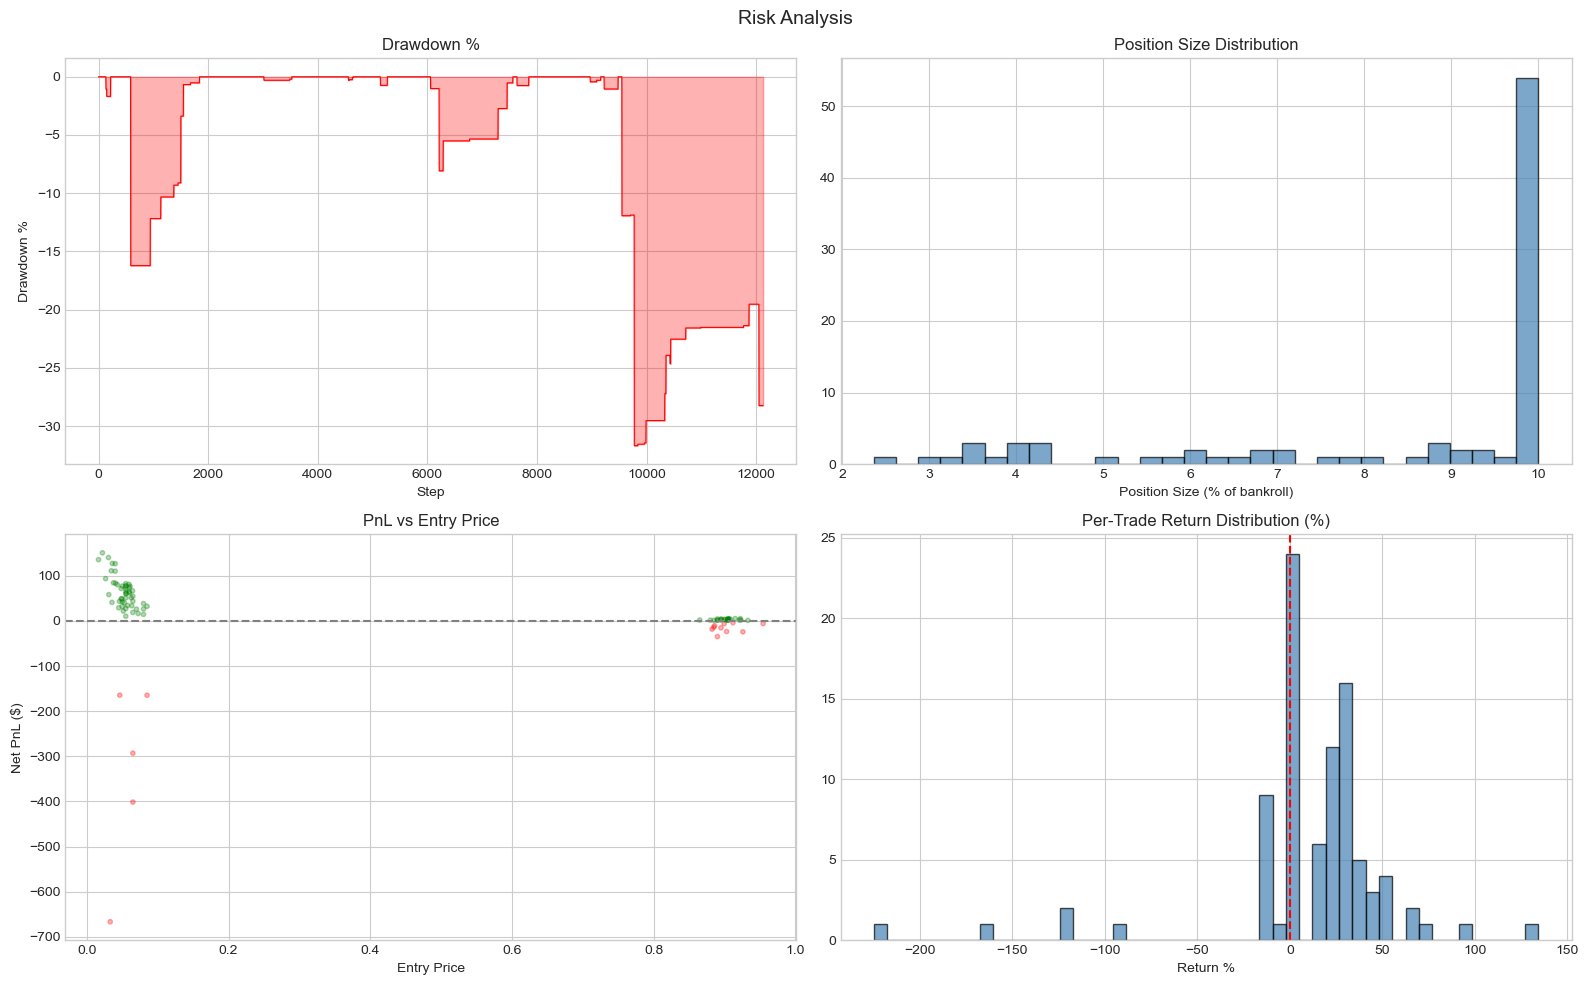

In [16]:
if len(wf_trades) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    axes[0,0].fill_between(range(len(dd)), -dd * 100, 0, color='red', alpha=0.3)
    axes[0,0].plot(-dd * 100, 'r-', linewidth=0.8)
    axes[0,0].set_title('Drawdown %')
    axes[0,0].set_xlabel('Step')
    axes[0,0].set_ylabel('Drawdown %')

    axes[0,1].hist(df_all_trades['pos_frac'] * 100, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0,1].set_title('Position Size Distribution')
    axes[0,1].set_xlabel('Position Size (% of bankroll)')

    axes[1,0].scatter(df_all_trades['p_market'], df_all_trades['net_pnl'],
                      c=df_all_trades['label'].map({1: 'green', 0: 'red'}), alpha=0.3, s=10)
    axes[1,0].axhline(y=0, color='gray', linestyle='--')
    axes[1,0].set_title('PnL vs Entry Price')
    axes[1,0].set_xlabel('Entry Price')
    axes[1,0].set_ylabel('Net PnL ($)')

    returns = df_all_trades['net_pnl'] / df_all_trades['bet_size']
    axes[1,1].hist(returns * 100, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[1,1].axvline(x=0, color='r', linestyle='--')
    axes[1,1].set_title('Per-Trade Return Distribution (%)')
    axes[1,1].set_xlabel('Return %')

    plt.suptitle('Risk Analysis', fontsize=14)
    plt.tight_layout()
    plt.show()

In [17]:
kelly_fracs = [0.10, 0.25, 0.33, 0.50, 0.75, 1.0]
kelly_results = []

for kf in kelly_fracs:
    trades, eq = simulate_trades(
        prob_test, test_prices, y_test,
        edge_threshold=best_threshold,
        kelly_frac=kf,
        max_pos=0.15,
        initial_bankroll=1000.0
    )
    m = compute_metrics(trades, eq)
    m['kelly_frac'] = kf
    kelly_results.append(m)

df_kelly = pd.DataFrame(kelly_results)
print('Kelly Fraction Sensitivity (Test Set):')
print(df_kelly[['kelly_frac', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']].to_string(index=False))

Kelly Fraction Sensitivity (Test Set):
 kelly_frac  n_trades  total_pnl_pct  win_rate  sharpe  max_dd
       0.10         0            0.0       0.0     0.0     0.0
       0.25         0            0.0       0.0     0.0     0.0
       0.33         0            0.0       0.0     0.0     0.0
       0.50         0            0.0       0.0     0.0     0.0
       0.75         0            0.0       0.0     0.0     0.0
       1.00         0            0.0       0.0     0.0     0.0


In [18]:
fee_rates = [0.00, 0.02, 0.05, 0.07, 0.10, 0.15, 0.20]
fee_results = []

for fr in fee_rates:

    FEE_RATE = fr

    trades, eq = simulate_trades(
        prob_test, test_prices, y_test,
        edge_threshold=best_threshold,
        kelly_frac=0.5,
        max_pos=0.10,
        initial_bankroll=1000.0
    )
    m = compute_metrics(trades, eq)
    m['fee_rate'] = fr
    fee_results.append(m)

FEE_RATE = 0.10

df_fees = pd.DataFrame(fee_results)
print('Fee Rate Sensitivity (Test Set):')
print(df_fees[['fee_rate', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']].to_string(index=False))

Fee Rate Sensitivity (Test Set):
 fee_rate  n_trades  total_pnl_pct  win_rate   sharpe   max_dd
     0.00       731     277.322795  0.726402 0.114899 0.230566
     0.02       179      74.504982  0.731844 0.112616 0.167501
     0.05        13      32.691223  0.923077 1.542951 0.004996
     0.07         4       6.729384  1.000000 4.107358 0.000000
     0.10         0       0.000000  0.000000 0.000000 0.000000
     0.15         0       0.000000  0.000000 0.000000 0.000000
     0.20         0       0.000000  0.000000 0.000000 0.000000


In [19]:
max_positions = [0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
pos_results = []

for mp in max_positions:
    trades, eq = simulate_trades(
        prob_test, test_prices, y_test,
        edge_threshold=best_threshold,
        kelly_frac=0.5,
        max_pos=mp,
        initial_bankroll=1000.0
    )
    m = compute_metrics(trades, eq)
    m['max_pos'] = mp
    pos_results.append(m)

df_pos = pd.DataFrame(pos_results)
print('Max Position Sensitivity (Test Set):')
print(df_pos[['max_pos', 'n_trades', 'total_pnl_pct', 'win_rate', 'sharpe', 'max_dd']].to_string(index=False))

Max Position Sensitivity (Test Set):
 max_pos  n_trades  total_pnl_pct  win_rate  sharpe  max_dd
    0.02         0            0.0       0.0     0.0     0.0
    0.05         0            0.0       0.0     0.0     0.0
    0.10         0            0.0       0.0     0.0     0.0
    0.15         0            0.0       0.0     0.0     0.0
    0.20         0            0.0       0.0     0.0     0.0
    0.30         0            0.0       0.0     0.0     0.0


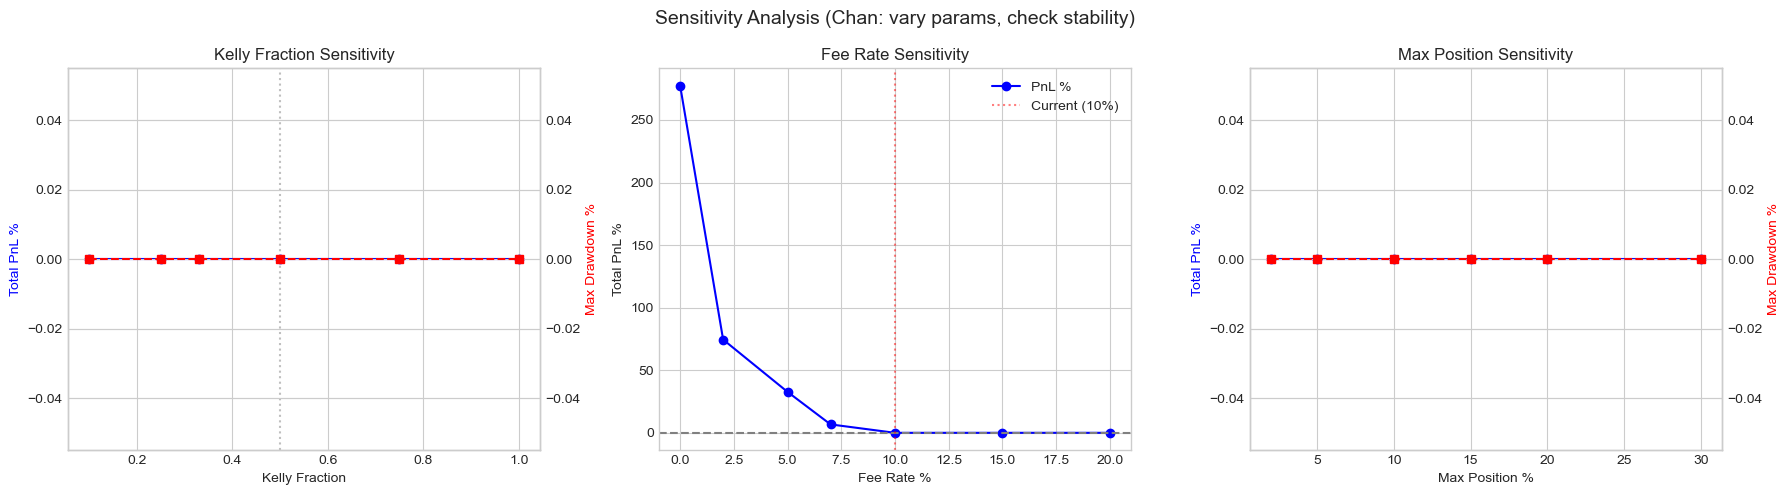

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(df_kelly['kelly_frac'], df_kelly['total_pnl_pct'], 'b-o', label='PnL %')
ax2 = ax.twinx()
ax2.plot(df_kelly['kelly_frac'], df_kelly['max_dd'] * 100, 'r--s', label='Max DD %')
ax.set_xlabel('Kelly Fraction')
ax.set_ylabel('Total PnL %', color='b')
ax2.set_ylabel('Max Drawdown %', color='r')
ax.set_title('Kelly Fraction Sensitivity')
ax.axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)

ax = axes[1]
ax.plot(df_fees['fee_rate'] * 100, df_fees['total_pnl_pct'], 'b-o', label='PnL %')
ax.axhline(y=0, color='gray', linestyle='--')
ax.set_xlabel('Fee Rate %')
ax.set_ylabel('Total PnL %')
ax.set_title('Fee Rate Sensitivity')
ax.axvline(x=10, color='r', linestyle=':', alpha=0.5, label='Current (10%)')
ax.legend()

ax = axes[2]
ax.plot(df_pos['max_pos'] * 100, df_pos['total_pnl_pct'], 'b-o', label='PnL %')
ax3 = ax.twinx()
ax3.plot(df_pos['max_pos'] * 100, df_pos['max_dd'] * 100, 'r--s', label='Max DD %')
ax.set_xlabel('Max Position %')
ax.set_ylabel('Total PnL %', color='b')
ax3.set_ylabel('Max Drawdown %', color='r')
ax.set_title('Max Position Sensitivity')

plt.suptitle('Sensitivity Analysis (Chan: vary params, check stability)', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
print('='*60)
print('PHASE 5.1 BACKTESTING SUMMARY')
print('='*60)
print(f'\nStrategy: Edge-based value trading (LGB Platt calibrated)')
print(f'Edge threshold: {best_threshold:.4f} (optimized on val set)')
print(f'Position sizing: Half-Kelly, max {0.10:.0%} per trade')
print(f'Fee model: Polymarket fee(p)=p*(1-p)*{FEE_RATE}, spread=${SPREAD}')

print(f'\n--- Test Set Results ---')
for k, v in test_metrics.items():
    if isinstance(v, float):
        print(f'  {k:>20}: {v:.4f}')
    else:
        print(f'  {k:>20}: {v}')

print(f'\n--- Walk-Forward Results ({len(wf_windows)} windows) ---')
for k, v in wf_overall.items():
    if isinstance(v, float):
        print(f'  {k:>20}: {v:.4f}')
    else:
        print(f'  {k:>20}: {v}')

print(f'\n--- Strategy Checklist (Chan ch.2) ---')
sharpe_ok = wf_overall.get('sharpe', 0) > 0
dd_ok = wf_overall.get('max_dd', 1) < 0.20
fees_ok = True
oos_ok = True
print(f'  Sharpe > 0:          {"PASS" if sharpe_ok else "FAIL"} ({wf_overall.get("sharpe", 0):.4f})')
print(f'  Max DD < 20%:        {"PASS" if dd_ok else "FAIL"} ({wf_overall.get("max_dd", 0):.1%})')
print(f'  Fees included:       PASS')
print(f'  OOS testing:         PASS (walk-forward)')
print(f'  Survivorship bias:   PASS (resolved markets included)')

PHASE 5.1 BACKTESTING SUMMARY

Strategy: Edge-based value trading (LGB Platt calibrated)
Edge threshold: 0.0010 (optimized on val set)
Position sizing: Half-Kelly, max 10% per trade
Fee model: Polymarket fee(p)=p*(1-p)*0.1, spread=$0.02

--- Test Set Results ---
              n_trades: 0
             total_pnl: 0.0000
         total_pnl_pct: 0.0000
              win_rate: 0.0000
                sharpe: 0.0000
                max_dd: 0.0000
               avg_pnl: 0.0000
          avg_pos_frac: 0.0000
            total_fees: 0.0000
      fee_pct_of_gross: 0.0000

--- Walk-Forward Results (5 windows) ---
              n_trades: 90
             total_pnl: 1414.8659
         total_pnl_pct: 141.4866
              win_rate: 0.8333
                sharpe: 0.2452
                max_dd: 0.3169
               avg_pnl: 15.7207
          avg_pos_frac: 0.0847
            total_fees: 7349.8520
      fee_pct_of_gross: 0.8386

--- Strategy Checklist (Chan ch.2) ---
  Sharpe > 0:          PASS (0.2452

In [22]:
import json

backtest_meta = {
    'strategy': 'edge_value_lgb_platt',
    'edge_threshold': float(best_threshold),
    'kelly_fraction': 0.5,
    'max_position': 0.10,
    'fee_rate': FEE_RATE,
    'spread': SPREAD,
    'tp_size': TP_SIZE,
    'sl_size': SL_SIZE,
    'initial_bankroll': INITIAL_BANKROLL,
    'test_set': {
        **{k: float(v) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v
           for k, v in test_metrics.items()}
    },
    'walk_forward': {
        'n_windows': len(wf_windows),
        **{k: float(v) if isinstance(v, (float, np.floating)) else int(v) if isinstance(v, (int, np.integer)) else v
           for k, v in wf_overall.items()}
    },
    'sensitivity': {
        'kelly_fracs_tested': kelly_fracs,
        'fee_rates_tested': fee_rates,
        'max_positions_tested': max_positions,
    },
    'seed': SEED
}

with open(MODELS / 'backtest_meta_v1.json', 'w') as f:
    json.dump(backtest_meta, f, indent=2, default=str)

if len(wf_trades) > 0:
    df_trade_log = pd.DataFrame(wf_trades)
    df_trade_log.to_parquet(DATA / 'processed' / 'backtest_trades_v1.parquet', index=False)
    print(f'Saved {len(df_trade_log)} trades to backtest_trades_v1.parquet')

pd.Series(wf_equity, name='equity').to_csv(DATA / 'processed' / 'backtest_equity_v1.csv', index=False)

print(f'Saved backtest_meta_v1.json')
print(f'Saved backtest_equity_v1.csv')
print(f'\nPhase 5.1 COMPLETE')

Saved 90 trades to backtest_trades_v1.parquet
Saved backtest_meta_v1.json
Saved backtest_equity_v1.csv

Phase 5.1 COMPLETE
